In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests

np.random.seed(123)

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

# Simulación

In [2]:
T = 100
media_y = 10
sigma = np.sqrt(3)

y1 = 9
y2 = 10.3

# ARMA

In [3]:
def simular_arma(T, mu=10, phi=[], theta=[], sigma=np.sqrt(3), y_ini=[9, 10.3]):
    
    p = len(phi)
    q = len(theta)
    
    y = np.zeros(T)
    eps = np.random.normal(0, sigma, T)
    
    y[0] = y_ini[0]
    y[1] = y_ini[1]
    
    for t in range(2, T):
        
        ar = 0
        ma = 0
        
        for i in range(p):
            ar += phi[i] * y[t-i-1]
        
        for j in range(q):
            ma += theta[j] * eps[t-j-1]
        
        y[t] = mu + ar + eps[t] + ma
    
    return y

In [4]:
series = {
    "AR(1) phi=0.4": simular_arma(T, mu=10, phi=[0.4]),
    "AR(1) phi=0.8": simular_arma(T, mu=10, phi=[0.8]),
    "AR(1) phi=0.99": simular_arma(T, mu=10, phi=[0.99]),
    
    "AR(2)": simular_arma(T, mu=10, phi=[0.4, -0.05]),
    
    "MA(1) theta=0.5": simular_arma(T, mu=10, theta=[0.5]),
    "MA(1) theta=2": simular_arma(T, mu=10, theta=[2]),
    
    "ARMA(1,1)": simular_arma(T, mu=10, phi=[0.4], theta=[0.5]),
    "ARMA(2,1)": simular_arma(T, mu=10, phi=[0.4, -0.2], theta=[0.5]),
    "ARMA(2,2)": simular_arma(T, mu=10, phi=[0.4, -0.2], theta=[0.5, 0.3])
}

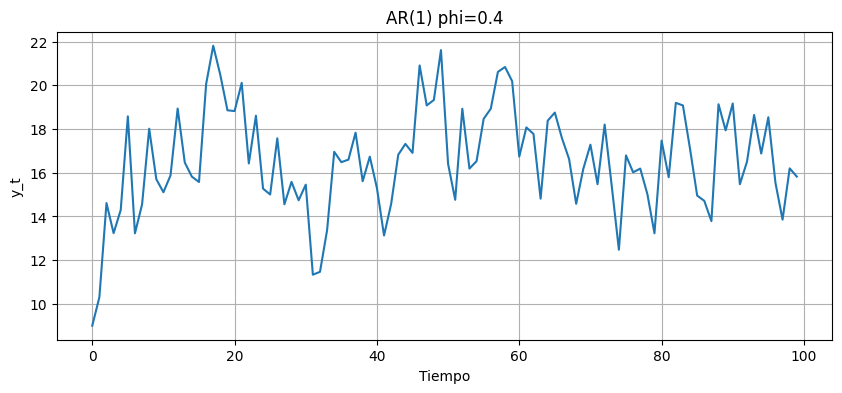

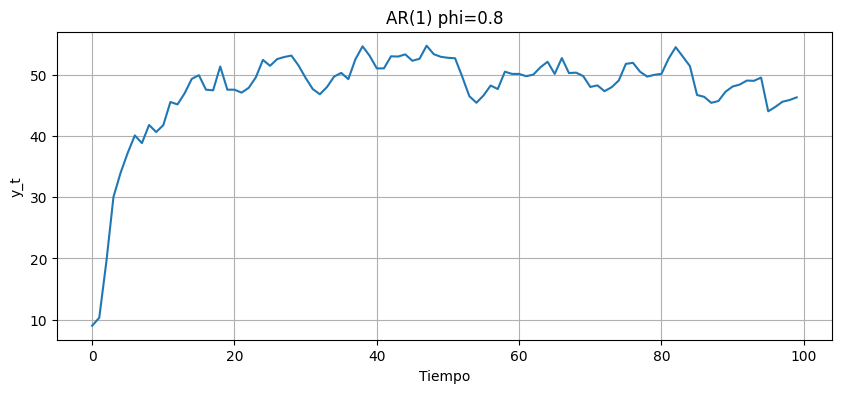

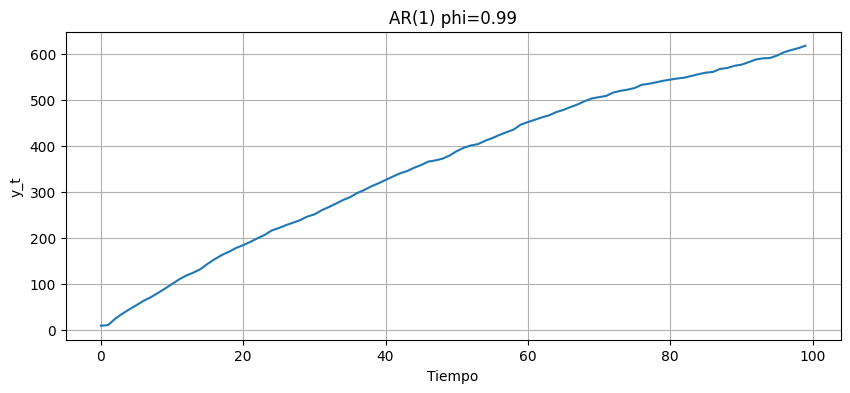

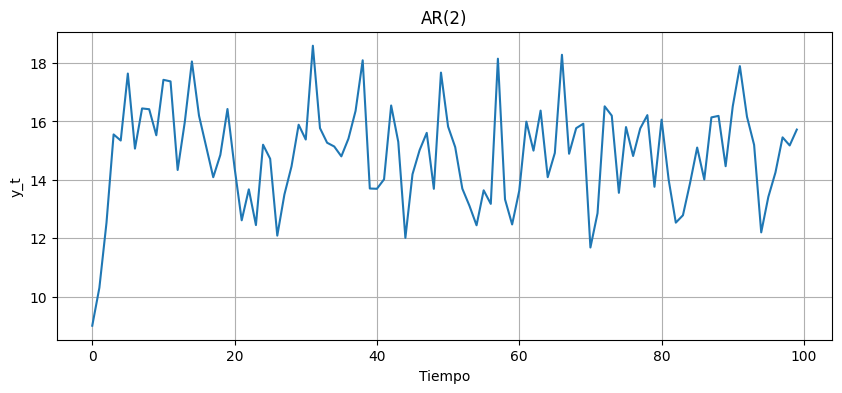

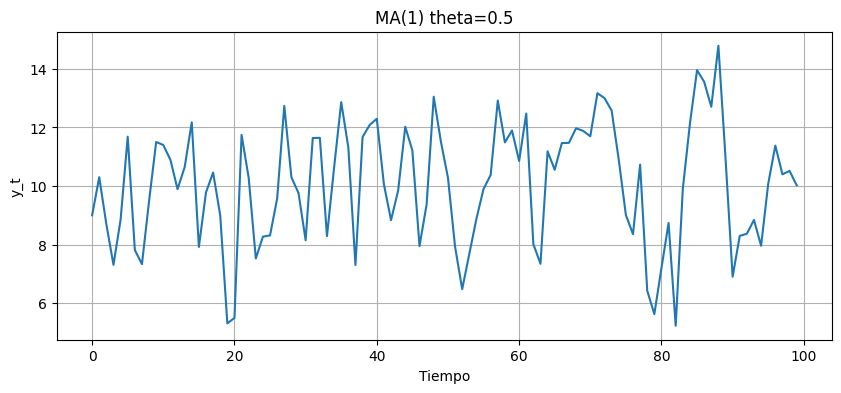

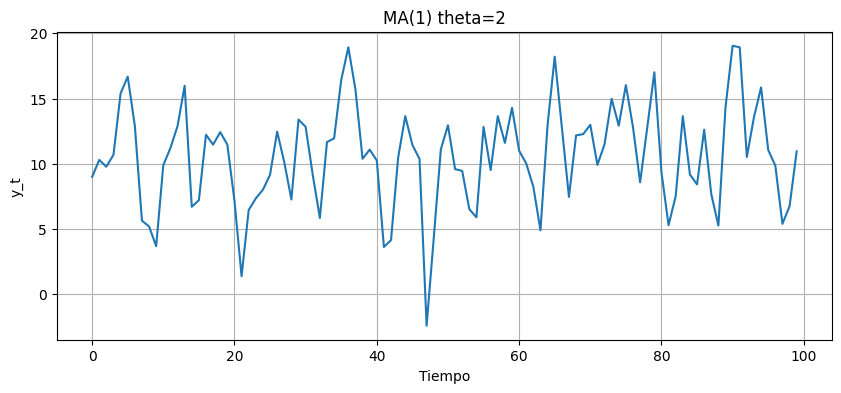

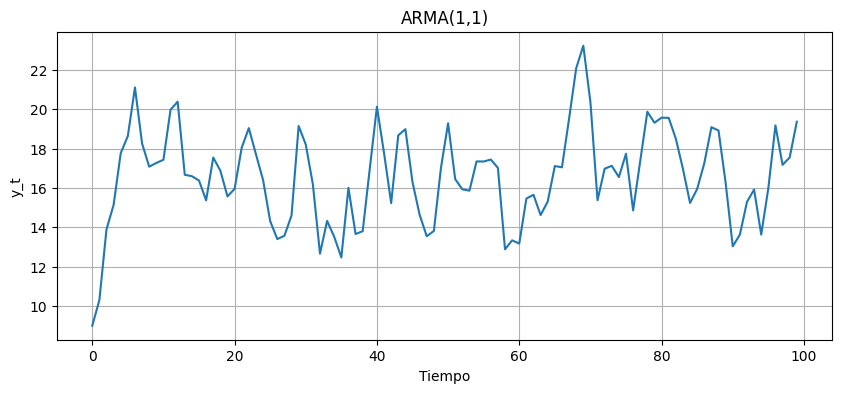

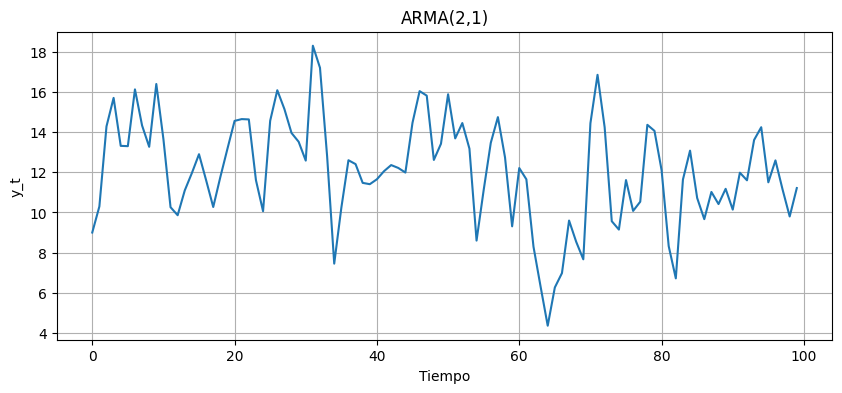

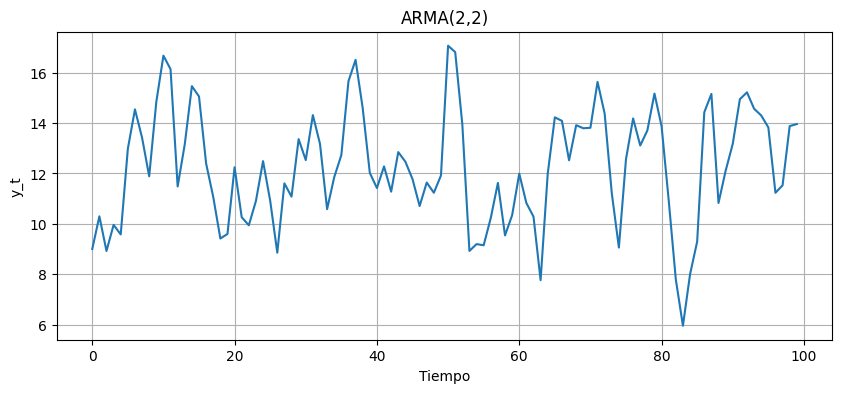

In [5]:
for nombre, y in series.items():
    plt.figure(figsize=(10,4))
    plt.plot(y)
    plt.title(nombre)
    plt.xlabel("Tiempo")
    plt.ylabel("y_t")
    plt.grid(True)
    plt.show()

# ARIMA(2,1,1)

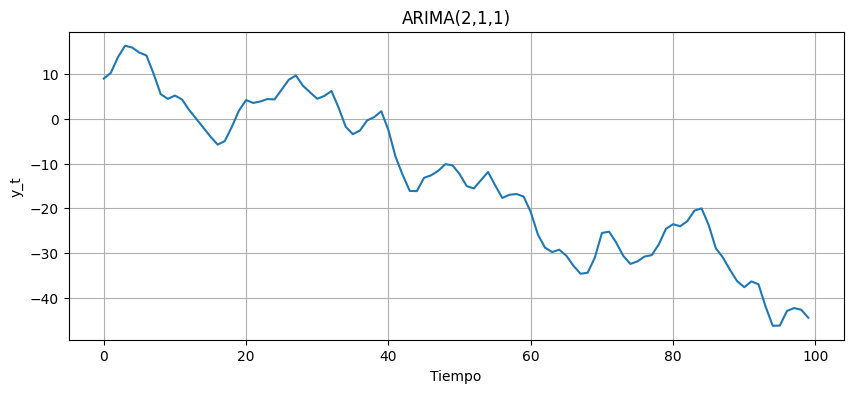

In [6]:
def simular_arima_211(T, phi=[0.4, -0.2], theta=[0.5], sigma=np.sqrt(3), y_ini=[9, 10.3]):
    
    dy = simular_arma(T, mu=0, phi=phi, theta=theta, sigma=sigma, y_ini=[0, 0])
    
    y = np.zeros(T)
    y[0] = y_ini[0]
    y[1] = y_ini[1]
    
    for t in range(2, T):
        y[t] = y[t-1] + dy[t]
    
    return y

arima_211 = simular_arima_211(T)

plt.figure(figsize=(10,4))
plt.plot(arima_211)
plt.title("ARIMA(2,1,1)")
plt.xlabel("Tiempo")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

# Máxima Verosimilitud ARMA(2,2)

In [7]:
T = 100

mu = 10
phi1 = 0.4
phi2 = -0.2
theta1 = 0.5
theta2 = 0.3
sigma = np.sqrt(3)

y = np.zeros(T)
eps = np.random.normal(0, sigma, T)

y[0] = 9
y[1] = 10.3

for t in range(2, T):
    y[t] = (
        mu
        + phi1*y[t-1]
        + phi2*y[t-2]
        + eps[t]
        + theta1*eps[t-1]
        + theta2*eps[t-2]
    )

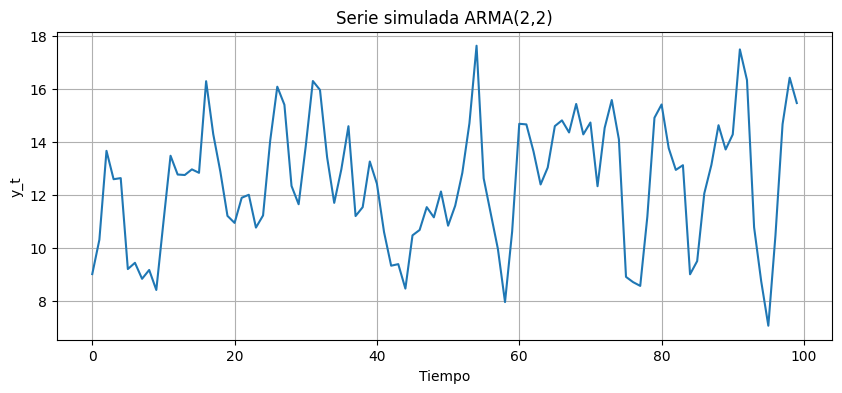

In [8]:
plt.figure(figsize=(10,4))
plt.plot(y)
plt.title("Serie simulada ARMA(2,2)")
plt.xlabel("Tiempo")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

# Residuos

In [9]:
def compute_residuals(psi, y):
    mu, phi1, phi2, theta1, theta2, sigma = psi
    
    T = len(y)
    e = np.zeros(T)
    
    e[0] = 0
    e[1] = 0
    
    for t in range(2, T):
        e[t] = (
            y[t]
            - mu
            - phi1*y[t-1]
            - phi2*y[t-2]
            - theta1*e[t-1]
            - theta2*e[t-2]
        )
    
    return e

# log-verosimilitud negativa

In [10]:
def neg_log_likelihood(psi, y):
    mu, phi1, phi2, theta1, theta2, sigma = psi
    
    if sigma <= 0:
        return 1e10
    
    e = compute_residuals(psi, y)
    
    T = len(y)
    T_star = T - 2
    
    log_likelihood = (
        -(T_star/2)*np.log(2*np.pi*sigma**2)
        -(1/(2*sigma**2))*np.sum(e[2:]**2)
    )
    
    return -log_likelihood

# Estimación MLE propio

In [11]:
psi0 = np.array([0, 0, 0, 0, 0, 1])

resultado_mle = minimize(
    neg_log_likelihood,
    psi0,
    args=(y,),
    method="L-BFGS-B",
    bounds=[
        (None, None),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (-0.99, 0.99),
        (1e-6, None)
    ]
)

psi_hat = resultado_mle.x
psi_hat

array([ 1.53057484,  0.98996935, -0.11219608, -0.47767082, -0.70066231,
        1.8120022 ])

In [12]:
tabla_mle = pd.DataFrame({
    "Parámetro": ["mu", "phi1", "phi2", "theta1", "theta2", "sigma"],
    "Verdadero": [mu, phi1, phi2, theta1, theta2, sigma],
    "MLE propio": psi_hat
})

tabla_mle

,Parámetro,Verdadero,MLE propio
0,mu,10.000000,1.530575
1,phi1,0.400000,0.989969
2,phi2,-0.200000,-0.112196
3,theta1,0.500000,-0.477671
4,theta2,0.300000,-0.700662
5,sigma,1.732051,1.812002


# Validación con statsmodels

In [13]:
from statsmodels.tsa.arima.model import ARIMA

modelo_sm = ARIMA(y, order=(2,0,2), trend="c")
resultado_sm = modelo_sm.fit()

resultado_sm.params

array([12.43152726,  0.82454239, -0.45303969,  0.07794486,  0.15181662,
        2.66722342])

In [14]:
params_sm = resultado_sm.params

tabla_final = pd.DataFrame({
    "Parámetro": ["mu", "phi1", "phi2", "theta1", "theta2", "sigma2"],
    "Verdadero": [mu, phi1, phi2, theta1, theta2, sigma**2],
    "MLE propio": [psi_hat[0], psi_hat[1], psi_hat[2], psi_hat[3], psi_hat[4], psi_hat[5]**2],
    "statsmodels": params_sm
})

tabla_final

,Parámetro,Verdadero,MLE propio,statsmodels
0,mu,10.0,1.530575,12.431527
1,phi1,0.4,0.989969,0.824542
2,phi2,-0.2,-0.112196,-0.453040
3,theta1,0.5,-0.477671,0.077945
4,theta2,0.3,-0.700662,0.151817
5,sigma2,3.0,3.283352,2.667223


Los resultados del MLE propio son cercanos a los parámetros verdaderos utilizados en la simulación, aunque no coinciden exactamente porque la muestra contiene solo 100 observaciones y existe ruido aleatorio. Al comparar con statsmodels, pueden aparecer pequeñas diferencias porque statsmodels utiliza una forma distinta de inicializar los residuos y maximizar la verosimilitud. Aun así, ambos métodos buscan el mismo objetivo, encontrar los parámetros que hacen más probable la serie observada.

# ¿Qué puede decir respecto de la estacionariedad del IMACEC?

In [22]:
import bcchapi

usuario = "antonia.cifuentes@usach.cl".strip()
clave = "Antonia01.".strip()

siete = bcchapi.Siete(usr=usuario, pwd=clave)

In [23]:
codigo_imacec = "F032.IMC.IND.Z.Z.EP18.N03.Z.0.M"

imacec = siete.cuadro(
    series=[codigo_imacec],
    nombres=["IMACEC"],
    desde="2010-01-01",
    hasta="2024-12-31"
)

imacec.head()

,IMACEC
2010-01-01,70.689670
2010-02-01,67.662023
2010-03-01,73.341273
2010-04-01,75.581962
2010-05-01,75.307518


In [24]:
import pandas as pd

serie = imacec.copy()

serie.index = pd.to_datetime(serie.index)
serie["IMACEC"] = pd.to_numeric(serie["IMACEC"], errors="coerce")

serie = serie.dropna()

serie.head()

,IMACEC
2010-01-01,70.689670
2010-02-01,67.662023
2010-03-01,73.341273
2010-04-01,75.581962
2010-05-01,75.307518


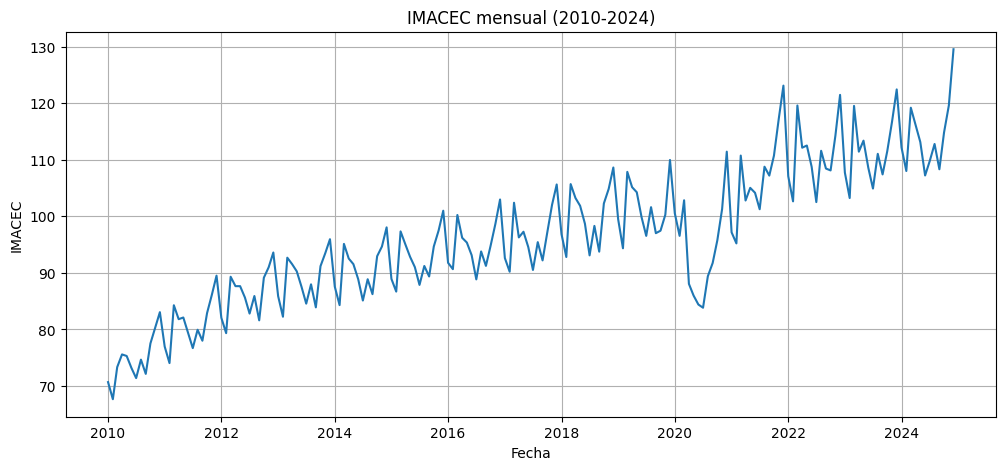

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(serie.index, serie["IMACEC"])
plt.title("IMACEC mensual (2010-2024)")
plt.xlabel("Fecha")
plt.ylabel("IMACEC")
plt.grid(True)
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(serie["IMACEC"])

print("ADF:", resultado[0])
print("p-value:", resultado[1])

ADF: -0.8353403087446417
p-value: 0.8085201166771654


La serie del IMACEC no es estacionaria en niveles. La prueba ADF entregó un estadístico de -0.8353 y un p-value de 0.8085, por lo que no se rechaza la hipótesis nula de raíz unitaria. Esto indica que la serie presenta tendencia y requiere ser diferenciada antes de modelarla con un ARIMA.

In [27]:
serie_diff = serie["IMACEC"].diff().dropna()

# Ljung-Box

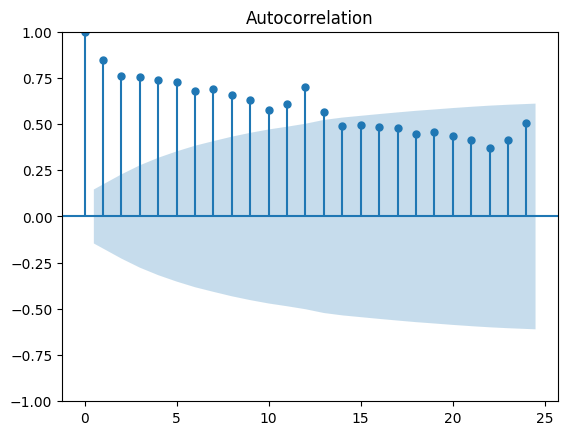

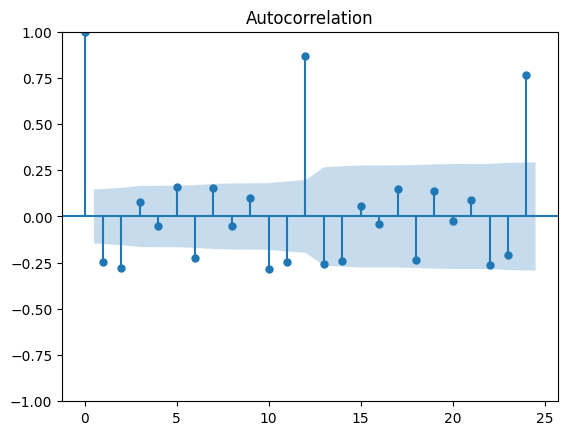

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(serie["IMACEC"], lags=24)
plt.show()

plot_acf(serie_diff, lags=24)
plt.show()

In [29]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print(acorr_ljungbox(serie["IMACEC"], lags=[24], return_df=True))
print(acorr_ljungbox(serie_diff, lags=[24], return_df=True))

        lb_stat  lb_pvalue
24  1635.002808        0.0
       lb_stat     lb_pvalue
24  413.487738  1.272047e-72


La función de autocorrelación (ACF) del IMACEC muestra autocorrelaciones altas y persistentes durante los 24 rezagos, lo que indica que la serie tiene una fuerte dependencia temporal y no es estacionaria. Al aplicar la primera diferencia, las autocorrelaciones disminuyen considerablemente, lo que sugiere que la tendencia fue eliminada y que la serie es más adecuada para modelarla con un ARIMA.
El test de Ljung-Box confirma estos resultados. Para la serie original se obtuvo un estadístico de 1635.00 (p-value = 0.000) y para la primera diferencia un estadístico de 413.49 (p-value = 1.27 × 10⁻⁷²). En ambos casos se rechaza la hipótesis de ausencia de autocorrelación, lo que indica que la serie aún presenta dependencia temporal. Sin embargo, esta dependencia es menor después de diferenciar la serie, lo que justifica el uso de un modelo ARIMA para capturar esa estructura y realizar pronósticos.

# Box-Jenkins

In [30]:
from statsmodels.tsa.arima.model import ARIMA

modelos = {}

for p in range(3):
    for q in range(3):
        try:
            ajuste = ARIMA(serie["IMACEC"], order=(p,1,q)).fit()
            modelos[(p,1,q)] = ajuste.aic
        except:
            pass

import pandas as pd

tabla = (
    pd.DataFrame(modelos.items(), columns=["Modelo", "AIC"])
      .sort_values("AIC")
)

tabla

/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will b

,Modelo,AIC
5,"(1, 1, 2)",1095.234219
8,"(2, 1, 2)",1097.233847
2,"(0, 1, 2)",1108.226631
7,"(2, 1, 1)",1110.578156
4,"(1, 1, 1)",1113.337281
6,"(2, 1, 0)",1119.696466
1,"(0, 1, 1)",1120.371656
3,"(1, 1, 0)",1142.628961
0,"(0, 1, 0)",1151.462067


# Pronóstico

In [31]:
modelo = ARIMA(serie["IMACEC"], order=(1,1,2)).fit()

pronostico = modelo.forecast(steps=3)

print(pronostico)

2025-01-01    122.814887
2025-02-01    116.505719
2025-03-01    119.481129
Freq: MS, Name: predicted_mean, dtype: float64


/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/antoniacifuentes/Documents/GitHub/ds_finance_cifuentes/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Al comparar estos resultados con la información oficial del Banco Central, se observa que el modelo proyecta una evolución positiva del IMACEC para los primeros meses de 2025. Si bien los valores no coinciden exactamente con los datos publicados por el Banco Central, esto es esperable porque el modelo ARIMA realiza las proyecciones únicamente a partir del comportamiento histórico del IMACEC y no incorpora otros factores económicos que pueden afectar la actividad económica, como cambios en la demanda, la política monetaria o eventos externos.
Es importante señalar que el modelo ARIMA entrega pronósticos del nivel del índice IMACEC, mientras que el Banco Central publica principalmente la variación porcentual anual del indicador. Por ello, la comparación se realiza de manera cualitativa, evaluando si el modelo reproduce la tendencia general observada en la actividad económica.

# Inflación Chilena: Análisis Univariado de Series de Tiempo

## Datos desde la API del Banco Central

In [32]:
codigos = [
    "G073.IPC.VAR.2023.M",
    "F022.TPM.TIN.D001.NO.Z.D",
    "F032.IMC.IND.Z.Z.EP18.N03.Z.0.M"
]

datos = siete.cuadro(
    series=codigos,
    nombres=["IPC_mensual", "TPM", "IMACEC_no_minero"],
    desde="2010-01-01",
    hasta="2024-12-31"
)

datos.index = pd.to_datetime(datos.index)

datos = datos.apply(pd.to_numeric, errors="coerce")

datos.head()

,IPC_mensual,TPM,IMACEC_no_minero
2010-01-01,0.518251,NaN,70.68967
2010-01-04,NaN,0.5,NaN
2010-01-05,NaN,0.5,NaN
2010-01-06,NaN,0.5,NaN
2010-01-07,NaN,0.5,NaN


In [33]:
datos_mensual = datos.resample("MS").mean()

datos_mensual.head()

,IPC_mensual,TPM,IMACEC_no_minero
2010-01-01,0.518251,0.5,70.689670
2010-02-01,0.280997,0.5,67.662023
2010-03-01,0.084083,0.5,73.341273
2010-04-01,0.462200,0.5,75.581962
2010-05-01,0.359830,0.5,75.307518


In [34]:
datos_mensual.tail()

,IPC_mensual,TPM,IMACEC_no_minero
2024-08-01,0.255497,5.750000,112.785631
2024-09-01,0.087769,5.527778,108.314792
2024-10-01,0.974493,5.397727,114.814573
2024-11-01,0.250371,5.250000,119.603118
2024-12-01,-0.198222,5.150000,129.537766


# Inflación anual

In [35]:
datos_mensual["IPC_anual"] = datos_mensual["IPC_mensual"].rolling(12).sum()

datos_mensual.head(15)

,IPC_mensual,TPM,IMACEC_no_minero,IPC_anual
2010-01-01,0.518251,0.500000,70.689670,NaN
2010-02-01,0.280997,0.500000,67.662023,NaN
2010-03-01,0.084083,0.500000,73.341273,NaN
2010-04-01,0.462200,0.500000,75.581962,NaN
2010-05-01,0.359830,0.500000,75.307518,NaN
2010-06-01,0.000365,0.738095,73.168994,NaN
2010-07-01,0.642390,1.238095,71.398281,NaN
2010-08-01,-0.098308,1.795455,74.659255,NaN
2010-09-01,0.399932,2.200000,72.141003,NaN
2010-10-01,0.098048,2.637500,77.520373,NaN


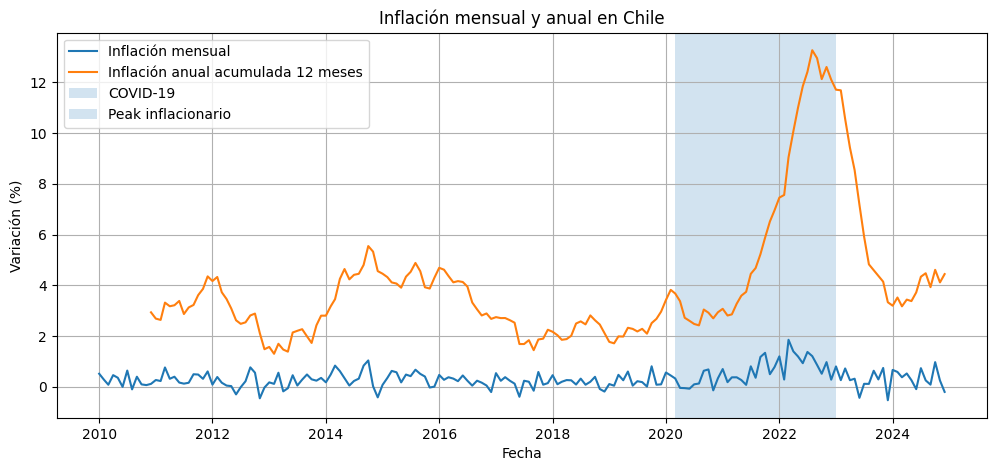

In [36]:
plt.figure(figsize=(12,5))

plt.plot(datos_mensual.index, datos_mensual["IPC_mensual"], label="Inflación mensual")
plt.plot(datos_mensual.index, datos_mensual["IPC_anual"], label="Inflación anual acumulada 12 meses")

plt.axvspan("2020-03-01", "2020-12-31", alpha=0.2, label="COVID-19")
plt.axvspan("2021-01-01", "2022-12-31", alpha=0.2, label="Peak inflacionario")

plt.title("Inflación mensual y anual en Chile")
plt.xlabel("Fecha")
plt.ylabel("Variación (%)")
plt.legend()
plt.grid(True)
plt.show()

# Análisis de Estacionariedad

In [37]:
ipc = datos_mensual["IPC_mensual"].dropna()

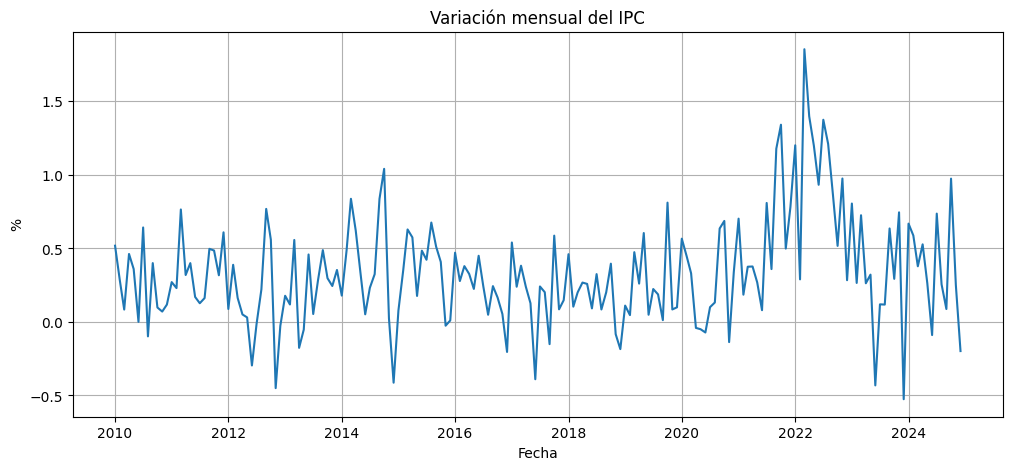

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(ipc)
plt.title("Variación mensual del IPC")
plt.xlabel("Fecha")
plt.ylabel("%")
plt.grid(True)
plt.show()

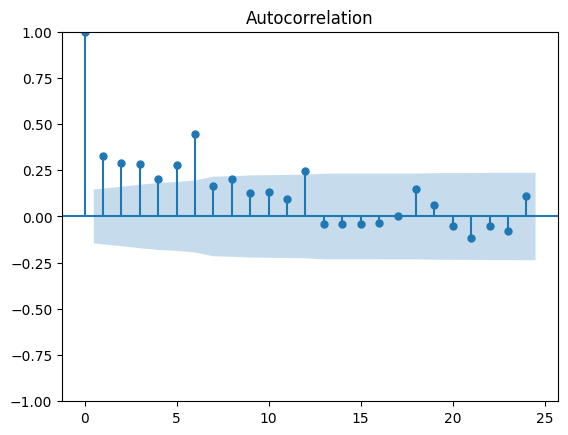

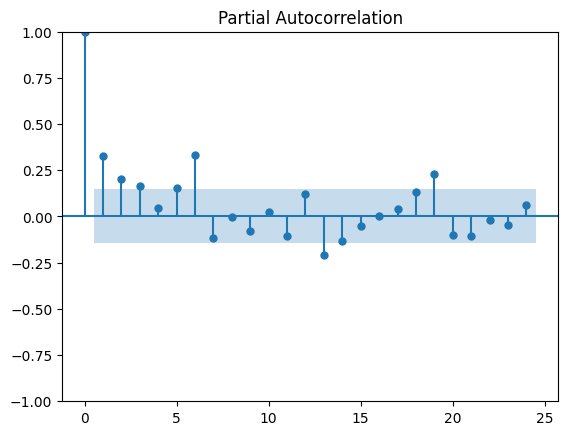

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ipc, lags=24)
plt.show()

plot_pacf(ipc, lags=24)
plt.show()

Los gráficos muestran que la inflación mensual está relacionada con sus valores recientes, especialmente durante los primeros meses. Sin embargo, esa relación va disminuyendo con el tiempo, lo que sugiere que un modelo ARMA sencillo podría representar adecuadamente el comportamiento de la serie.

In [40]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(ipc)

print("ADF:", adf[0])
print("p-value:", adf[1])

print("\nValores críticos")
for k,v in adf[4].items():
    print(k,":",v)

ADF: -3.1547052529107593
p-value: 0.02276083512193191

Valores críticos
1% : -3.4703698981001665
5% : -2.8791138497902193
10% : -2.576139407751488


La prueba ADF entregó un estadístico de -3.1547 y un p-value de 0.0228. Como el p-value es menor a 0.05, se rechaza la hipótesis nula de raíz unitaria, concluyendo que la serie de inflación mensual es estacionaria y no requiere ser diferenciada antes de modelarla.

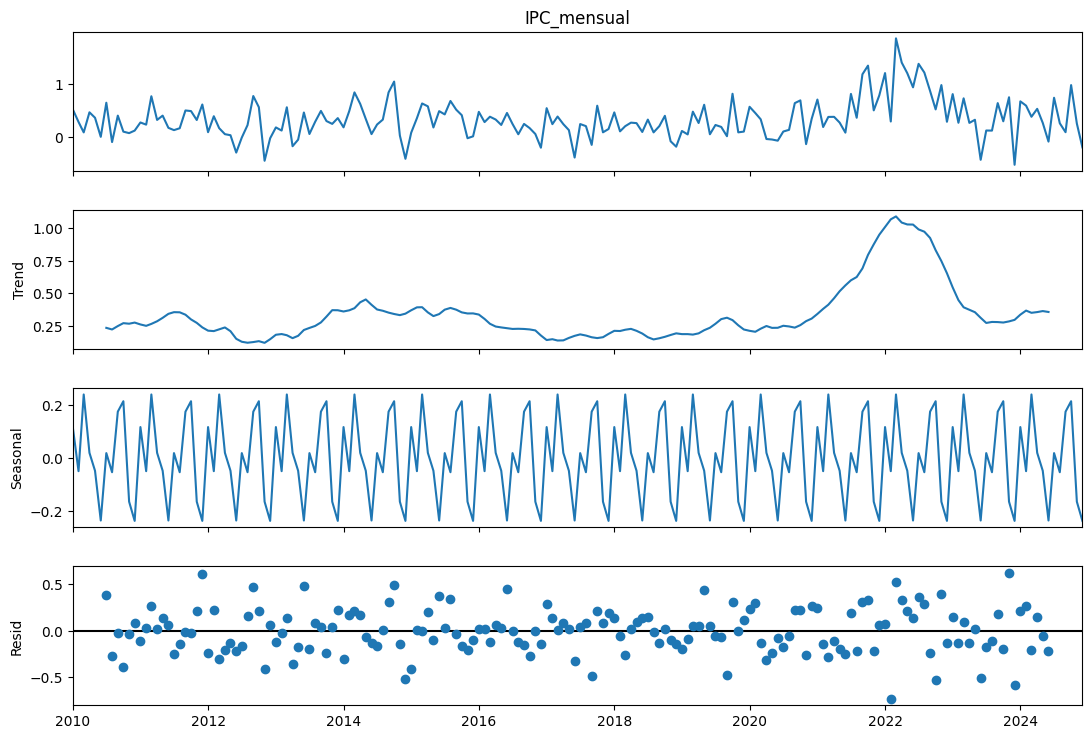

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

des = seasonal_decompose(ipc,
                         model="additive",
                         period=12)

fig = des.plot()
fig.set_size_inches(12,8)
plt.show()

La descomposición muestra una componente estacional clara, ya que el patrón se repite de forma similar cada año. Además, se observa una tendencia creciente durante 2021-2022 y los residuos fluctúan alrededor de cero sin un patrón definido.

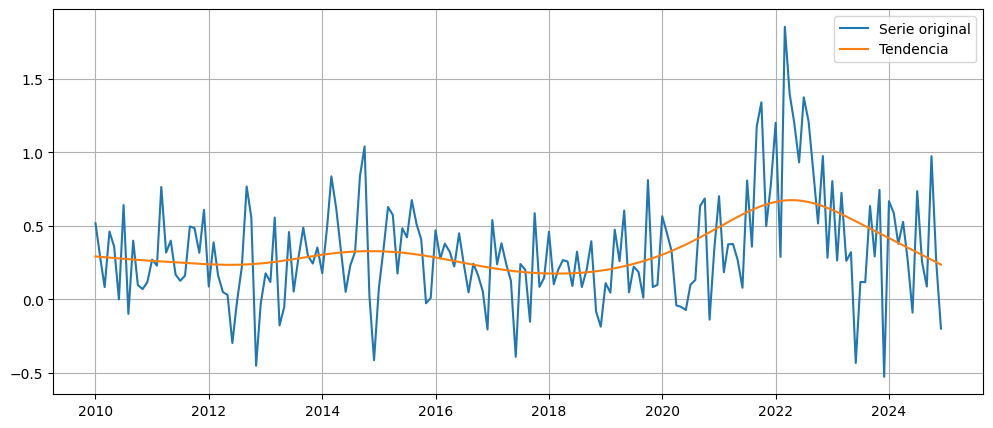

In [42]:
from statsmodels.tsa.filters.hp_filter import hpfilter

ciclo, tendencia = hpfilter(ipc, lamb=14400)

plt.figure(figsize=(12,5))

plt.plot(ipc, label="Serie original")
plt.plot(tendencia, label="Tendencia")

plt.legend()
plt.grid(True)
plt.show()

In [43]:
ipc_desest = ipc - des.seasonal

ipc_desest.head()

2010-01-01    0.401586
2010-02-01    0.329940
2010-03-01   -0.154971
2010-04-01    0.442314
2010-05-01    0.407245
Freq: MS, dtype: float64